# <a id='toc1_'></a>[<span style="color:yellow;">Object Detection</span>](#toc0_)

In [1]:
import sys
print("当前解释器:", sys.executable)


当前解释器: c:\Users\saltz\AppData\Local\Programs\Python\Python312\python.exe


**Table of contents**<a id='toc0_'></a>    
- [<span style="color:yellow;">Object Detection</span>](#toc1_)    
- [Step 1: Import necessary libraries](#toc2_)    
  - [Step 1.1: Import core libraries](#toc2_1_)    
  - [Step 1.2: Import visualization libraries](#toc2_2_)    
  - [Step 1.3: Import network and file handling utilities](#toc2_3_)    
  - [Step 1.4: Import ML framework and model](#toc2_4_)    
  - [Step 1.5: Configure Jupyter notebook](#toc2_5_)    
- [Step 2: Load the pre-trained YOLOv8 model](#toc3_)    
  - [Step 2.1: Initialize the YOLO model](#toc3_1_)    
  - [Step 2.2: Verify model loading and basic properties](#toc3_2_)    
  - [Step 2.3: Analyze model file size](#toc3_3_)    
  - [Step 2.4: Calculate model parameters](#toc3_4_)    
  - [Step 2.5: Estimate model memory usage](#toc3_5_)    
- [Step 3: Load an image and preprocess it](#toc4_)    
  - [Step 3.1: Define image path](#toc4_1_)    
  - [Step 3.2: Load the image using OpenCV](#toc4_2_)    
  - [Step 3.3: Preprocess the image](#toc4_3_)    
  - [Step 3.4: Display the resized image](#toc4_4_)    
- [Step 4: Perform object detection using YOLO](#toc5_)    
  - [Step 4.1: Run inference with the YOLOv8 model](#toc5_1_)    
  - [Step 4.2: Extract and validate bounding box data](#toc5_2_)    
  - [Step 4.3: Decode key detection metadata](#toc5_3_)    
- [Step 5: Visualize the detection results](#toc6_)    
  - [Step 5.1: Prepare a "canvas" for drawing](#toc6_1_)    
  - [Step 5.2: Define class-specific colors](#toc6_2_)    
  - [Step 5.3: Draw bounding boxes for detected objects](#toc6_3_)    
  - [Step 5.4: Add class names and confidence scores](#toc6_4_)    
  - [Step 5.5: Display the final visualization](#toc6_5_)    
    - [Step 5.5.1: Convert canvas](#toc6_5_1_)    
    - [Step 5.5.2: Configure and display](#toc6_5_2_)    
    - [Step 5.5.3: Proper layout and Rendering](#toc6_5_3_)    
  - [Step 5.6: Verify visualization](#toc6_6_)    
- [Step 6: Analyze detection results](#toc7_)    
  - [Step 6.1: Calculate class-wise object counts](#toc7_1_)    
  - [Step 6.2: Visualize class distribution with a bar chart](#toc7_2_)    
  - [Step 6.3: Extract and bin confidence scores](#toc7_3_)    
    - [Step 6.3.1: Extract all confidence scores from detections](#toc7_3_1_)    
    - [Step 6.3.2: Define confidence bins](#toc7_3_2_)    
    - [Step 6.3.3: Assign each confidence score to its bin](#toc7_3_3_)    
    - [Step 6.3.4: Verify bin count consistency](#toc7_3_4_)    
  - [Step 7: Visualize confidence score distribution](#toc7_4_)    
    - [Step 7.1: High-contrast, saturated colors](#toc7_4_1_)    
    - [Step 7.2: Create a square figure](#toc7_4_2_)    
    - [Step 7.3: Generate the pie chart](#toc7_4_3_)    
    - [Step 7.4: Dynamic text color for percentages](#toc7_4_4_)    
    - [Step 7.5: Add title](#toc7_4_5_)    
    - [Step 7.6: Finalize layout, and display](#toc7_4_6_)    
  - [Step 8: Summarize](#toc7_5_)    
- [Reference](#toc8_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Step 1: Import necessary libraries](#toc0_)

## <a id='toc2_1_'></a>[Step 1.1: Import core libraries](#toc0_)
These libraries form the foundation for `image processing` and `numerical operations` required for `object detection`.

In [2]:
import cv2          # OpenCV: For image loading, processing, and visualization
import numpy as np  # NumPy: For numerical operations and array manipulations

## <a id='toc2_2_'></a>[Step 1.2: Import visualization libraries](#toc0_)
- These libraries are used for displaying images 
- and working with different image formats.

In [3]:
import matplotlib.pyplot as plt  # Matplotlib: For plotting and image display
from PIL import Image            # PIL: For additional image processing capabilities

## <a id='toc2_3_'></a>[Step 1.3: Import network and file handling utilities](#toc0_)
These libraries help with downloading images from URLs and managing file system operations.

In [4]:
import requests          # Requests: For downloading images from URLs
from io import BytesIO   # BytesIO: For handling image data as byte streams
import os                # OS: For interacting with the file system

## <a id='toc2_4_'></a>[Step 1.4: Import ML framework and model](#toc0_)
These are the core components for loading and running the `YOLOv8` `object detection` model.

In [5]:
import torch               # PyTorch: The deep learning framework used by YOLOv8
from ultralytics import YOLO  # YOLO: The object detection model from Ultralytics

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\saltz\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


- 🚀 **Leading open-source software/framework** for simplifying *state-of-the-art (SOTA) computer vision (CV) development*.  
- 🎯 Focuses on key CV tasks: **object detection**, segmentation, classification, pose estimation, tracking.  
- 🎯 Mission: Lower barrier to entry for *advanced CV tech*, making it accessible beyond experts.  
- 🌟 Best known for flagship project **YOLOv8** (*latest YOLO series iteration*).  
- ⚡ YOLOv8 revolutionized real-time object detection with balanced **speed**, **accuracy**, and *ease of use*.

<img src="Image/yolo.png" width=300>

## <a id='toc2_5_'></a>[Step 1.5: Configure Jupyter notebook](#toc0_)
This special command ensures that matplotlib figures are displayed directly in the notebook.

In [6]:
# For inline image display in Jupyter notebooks
%matplotlib inline

In [7]:
print("Step 1: Libraries imported successfully\n")

Step 1: Libraries imported successfully



# <a id='toc3_'></a>[Step 2: Load the pre-trained YOLOv8 model](#toc0_)

## <a id='toc3_1_'></a>[Step 2.1: Initialize the YOLO model](#toc0_)
- The code loads the `YOLOv8 nano` model, which is a lightweight version of the `YOLOv8` architecture. 

- The '*n*' in 'yolov8n.pt' stands for "*nano*", indicating this is the smallest and fastest model in the `YOLOv8` family.

In [8]:
model = YOLO('yolov8n.pt')  # 'n' stands for nano, a lightweight version

## <a id='toc3_2_'></a>[Step 2.2: Verify model loading and basic properties](#toc0_)
This section confirms that the model loaded successfully and displays key information about the model architecture and capabilities.

In [9]:
print("Step 2: YOLOv8 model loaded successfully")
print(f"Model name: {model.model.__class__.__name__}")
print(f"Number of classes: {len(model.names)}")
print(f"First 10 classes: {list(model.names.values())[:10]}\n")

Step 2: YOLOv8 model loaded successfully
Model name: DetectionModel
Number of classes: 80
First 10 classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light']



## <a id='toc3_3_'></a>[Step 2.3: Analyze model file size](#toc0_)
This code checks if the model file exists locally and calculates its size in megabytes (MB), providing insight into the storage requirements of the model.

In [10]:
# Get model file size
if os.path.exists('yolov8n.pt'):
    file_size = os.path.getsize('yolov8n.pt') / (1024 * 1024)  # Convert to MB
    print(f"Model file size: {file_size:.2f} MB")

Model file size: 6.25 MB


## <a id='toc3_4_'></a>[Step 2.4: Calculate model parameters](#toc0_)
This section counts the total number of parameters in the model, which is a key indicator of model complexity. The parameter count helps understand the model's capacity and computational requirements.

In [11]:
# Calculate number of parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,} (~{total_params/1e6:.1f} million)")

Total parameters: 3,157,200 (~3.2 million)


## <a id='toc3_5_'></a>[Step 2.5: Estimate model memory usage](#toc0_)
This code approximates the memory required to store the model in RAM by assuming each parameter is stored as a 32-bit float (4 bytes), giving an indication of the runtime memory requirements.

In [12]:
# Calculate model size in memory (approximate)
# Each parameter is typically a 32-bit float (4 bytes)
model_memory_size = total_params * 4 / (1024 * 1024)  # Convert to MB
print(f"Approximate memory usage: {model_memory_size:.2f} MB\n")

Approximate memory usage: 12.04 MB



# <a id='toc4_'></a>[Step 3: Load an image and preprocess it](#toc0_)

## <a id='toc4_1_'></a>[Step 3.1: Define image path](#toc0_)

In [98]:
image_path = 'match.jpg'  # Local image file

## <a id='toc4_2_'></a>[Step 3.2: Load the image using OpenCV](#toc0_)

In [99]:
# Load image using OpenCV
img_cv = cv2.imread(image_path)

In [100]:
# Define h (height) and w (width)
h, w = img_cv.shape[:2]  # shape[:2] = (height, width) (ignore channels)

## <a id='toc4_3_'></a>[Step 3.3: Preprocess the image](#toc0_)
`YOLOv8` can accept images of varying sizes, but resizing to a smaller, consistent maximum dimension offers two key benefits:

- Faster inference: 
    - Smaller images reduce the number of computations the model needs to perform.
- Memory efficiency: 
    - Smaller images use less RAM, 
    - which is critical for edge devices (e.g., Raspberry Pi) or batch processing.

In [101]:
# Define the maximum target dimension (256 pixels for width/height)
max_dim = 600

# Calculate the scaling factor to resize the image without distorting it
# The scaling factor is the ratio of max_dim to the larger of the original width/height
scale = max_dim / max(h, w)  # Ensures the largest side (width or height) becomes max_dim

# Calculate the new dimensions (width and height) after scaling
# Convert to integers (pixels must be whole numbers)
new_w, new_h = int(w * scale), int(h * scale)

# Resize the image using OpenCV's cv2.resize()
# Interpolation method: cv2.INTER_AREA is ideal for downsampling (preserves detail better than other methods)
img_resized = cv2.resize(img_cv, (new_w, new_h), interpolation=cv2.INTER_AREA)

# Print preprocessing details
print(f"✅ Image preprocessing (resize) completed")
print(f"📏 Resized image dimensions: Width = {new_w} pixels, Height = {new_h} pixels")
print(f"📊 Scaling factor applied: {scale:.2f}x (original → resized)")
print(f"🔒 Aspect ratio preserved: Original aspect ratio = {w/h:.2f}, Resized aspect ratio = {new_w/new_h:.2f}")

✅ Image preprocessing (resize) completed
📏 Resized image dimensions: Width = 600 pixels, Height = 336 pixels
📊 Scaling factor applied: 0.56x (original → resized)
🔒 Aspect ratio preserved: Original aspect ratio = 1.78, Resized aspect ratio = 1.79


## <a id='toc4_4_'></a>[Step 3.4: Display the resized image](#toc0_)

In [102]:
# Create a Matplotlib figure for display
plt.ioff()
plt.figure(figsize=(3, 2))  # (width, height) in inches

<Figure size 300x200 with 0 Axes>

In [103]:
# Convert BGR (OpenCV) → RGB (Matplotlib) for correct color display
img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

In [104]:
# Display the image
plt.imshow(img_rgb)
plt.title(f"Original Image\n (Resized to Max {max_dim}x{max_dim} Pixels)", fontsize=10, pad=10)
plt.axis('off')  # Hide x/y axes to avoid cluttering the display

(np.float64(-0.5), np.float64(599.5), np.float64(335.5), np.float64(-0.5))

ValueError: need at least one array to concatenate

<Figure size 400x400 with 1 Axes>

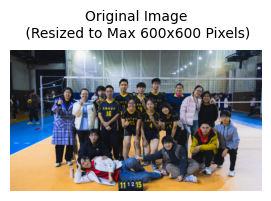

In [105]:
# Ensure the image is rendered properly (critical for Jupyter notebooks)
plt.tight_layout()
plt.show()

In [106]:
# Final confirmation for Step 3
print(f"\n✅ Step 3: Image loading and preprocessing fully completed")


✅ Step 3: Image loading and preprocessing fully completed


# <a id='toc5_'></a>[Step 4: Perform object detection using YOLO](#toc0_)

- `Object detection` is the core step of the pipeline—here, 
- the pre-trained `YOLOv8` model processes the preprocessed image 
    - to identify objects, 
    - predict their classes, 
    - and localize them with `bounding boxes`.

## <a id='toc5_1_'></a>[Step 4.1: Run inference with the YOLOv8 model](#toc0_)
Inference is the process of feeding the preprocessed image into the model and generating detection results. 

The YOLOv8 model automates most steps (e.g., normalization, padding) under the hood, so we only need to pass the resized image to the model.

In [107]:
results = model(img_resized)

print("Step 4: Object detection completed successfully")
print(f"Number of detected objects: {len(results[0].boxes)}")


0: 384x640 18 persons, 1 baseball glove, 112.0ms
Speed: 3.6ms preprocess, 112.0ms inference, 3.9ms postprocess per image at shape (1, 3, 384, 640)
Step 4: Object detection completed successfully
Number of detected objects: 19


In [108]:
print(f"✅ Step 4.1: YOLOv8 inference completed successfully")

# `results` — The top-level inference output object
# Type: ultralytics.engine.results.Results (a list-like object, even for single images)
# Purpose: Stores all detection data for the input image(s) (here, 1 image → results[0] is the first/only result)
print(f"\n🔍 Key Variable: `results`")
print(f"   - Type: {type(results)}")
print(f"   - Number of images processed: {len(results)} (we input 1 image, so len(results) = 1)")
print(f"   - Contents: Each element in `results` is a Results object for one input image")

# Extract the Results object for our single image (critical for downstream analysis)
single_image_results = results[0]
print(f"\n🔍 Key Variable: `single_image_results` (extracted from results[0])")
print(f"   - Type: {type(single_image_results)}")
print(f"   - Purpose: Stores all detection data for the single input image (bounding boxes, classes, confidences, etc.)")
print(f"   - Core attributes: {[attr for attr in dir(single_image_results) if not attr.startswith('_')][:10]}... (e.g., 'boxes', 'masks', 'probs')")

✅ Step 4.1: YOLOv8 inference completed successfully

🔍 Key Variable: `results`
   - Type: <class 'list'>
   - Number of images processed: 1 (we input 1 image, so len(results) = 1)
   - Contents: Each element in `results` is a Results object for one input image

🔍 Key Variable: `single_image_results` (extracted from results[0])
   - Type: <class 'ultralytics.engine.results.Results'>
   - Purpose: Stores all detection data for the single input image (bounding boxes, classes, confidences, etc.)
   - Core attributes: ['boxes', 'cpu', 'cuda', 'keypoints', 'masks', 'names', 'new', 'numpy', 'obb', 'orig_img']... (e.g., 'boxes', 'masks', 'probs')


## <a id='toc5_2_'></a>[Step 4.2: Extract and validate bounding box data](#toc0_)
- The most critical output of object detection is `bounding boxes`
- they define the location of each detected object in the image. 
- `YOLOv8` stores `bounding box` data (and related metadata like class IDs) in the boxes attribute of the Results object.

In [109]:
# Extract bounding boxes and detection metadata from the Results object
# `detections` (aliased from single_image_results.boxes)
# Type: ultralytics.engine.results.Boxes
# Purpose: Stores all detection data for individual objects (bounding boxes, class IDs, confidences)
detections = single_image_results.boxes

# Verify detections were extracted correctly
print(f"\n✅ Step 4.2: Bounding box data extracted successfully")
print(f"🔍 Key Variable: `detections` (single_image_results.boxes)")
print(f"   - Type: {type(detections)}")
print(f"   - Number of detected objects: {len(detections)} (core metric for detection success)")
print(f"   - Core attributes: {[attr for attr in dir(detections) if not attr.startswith('_')][:8]}... (e.g., 'cls', 'conf', 'xyxy')")

# If no objects are detected, log a message and skip detailed analysis
print(f"\n✅ Detected {len(detections)} object(s) — proceeding to detailed analysis.")


✅ Step 4.2: Bounding box data extracted successfully
🔍 Key Variable: `detections` (single_image_results.boxes)
   - Type: <class 'ultralytics.engine.results.Boxes'>
   - Number of detected objects: 19 (core metric for detection success)
   - Core attributes: ['cls', 'conf', 'cpu', 'cuda', 'data', 'id', 'is_track', 'numpy']... (e.g., 'cls', 'conf', 'xyxy')

✅ Detected 19 object(s) — proceeding to detailed analysis.


## <a id='toc5_3_'></a>[Step 4.3: Decode key detection metadata](#toc0_)
For each detected object, the detections object stores three critical pieces of metadata. We decode these below to make them human-readable:

- cls: Class ID of the detected object (maps to a class name via model.names).
- conf: Confidence score ($0–1$) — how sure the model is about the class prediction.
- xyxy: Bounding box coordinates ($x1, y1, x2, y2$) — top-left ($x1,y1$) and bottom-right ($x2,y2$) corners.

In [110]:
print(f"\n✅ Step 4.3: Decoding detection metadata for each object")

# Define YOLOv8's default confidence threshold (critical for context)
# Note: YOLOv8 uses a default confidence threshold of 0.25 to filter low-confidence detections
DEFAULT_CONF_THRESHOLD = 0.25

# Loop through the first 5 detections (to avoid cluttering output; remove [:5] to see all)
for i, box in enumerate(detections[:5]):
    print(f"\n📌 Object {i+1}/{len(detections)}")
    
    # 1. Decode Class ID (`cls`)
    # Key Attribute: box.cls — Tensor of class IDs (shape: [1] per object)
    class_id_tensor = box.cls
    class_id = int(class_id_tensor.item())  # Convert tensor to integer (safe for single-object tensors)
    class_name = model.names[class_id]      # Map numeric ID to human-readable class name (from YOLO's 80 predefined classes)
    print(f"   🔹 Class ID (`box.cls`):")
    print(f"      - Type: {type(class_id_tensor)} (PyTorch Tensor, stores numeric class ID)")
    print(f"      - Raw tensor value: {class_id_tensor} → Converted to integer: {class_id}")
    print(f"      - Mapped class name: {class_name} (lookup via `model.names[{class_id}]`)")
    
    # 2. Decode Confidence Score (`conf`)
    # Key Attribute: box.conf — Tensor of confidence scores (shape: [1] per object, range 0–1)
    confidence_tensor = box.conf
    confidence = float(confidence_tensor.item())  # Convert tensor to float for readability
    # Add context: Compare confidence to YOLOv8's default threshold
    conf_status = "✅ Above default threshold" if confidence >= DEFAULT_CONF_THRESHOLD else "⚠️ Below default threshold (unlikely to be included in results)"
    print(f"   🔹 Confidence Score (`box.conf`):")
    print(f"      - Type: {type(confidence_tensor)} (PyTorch Tensor, measures prediction certainty)")
    print(f"      - Raw tensor value: {confidence_tensor} → Converted to float: {confidence:.4f}")
    print(f"      - Context: {conf_status} (YOLOv8 default threshold: {DEFAULT_CONF_THRESHOLD})")
    print(f"      - Interpretation: The model is {confidence*100:.2f}% confident this object is a '{class_name}'")
    
    # 3. Decode Bounding Box Coordinates (`xyxy`)
    # Key Attribute: box.xyxy — Tensor of coordinates (shape: [1,4] per object; format: [x1, y1, x2, y2])
    # Critical note: Coordinates are relative to the RESIZED image (not the original) — matches Step 3's preprocessing
    bbox_tensor = box.xyxy
    # Extract coordinates (box.xyxy returns [1,4] tensor for 1 object; [0] gets the [x1,y1,x2,y2] list)
    bbox = bbox_tensor[0].tolist()
    # Convert to integers (pixels are whole numbers; rounding is safe for visualization)
    x1, y1, x2, y2 = map(int, bbox)
    # Calculate bounding box size (useful for understanding object scale in the resized image)
    bbox_width = x2 - x1
    bbox_height = y2 - y1
    print(f"   🔹 Bounding Box (`box.xyxy`):")
    print(f"      - Type: {type(bbox_tensor)} (PyTorch Tensor, stores pixel coordinates)")
    print(f"      - Raw tensor value: {bbox_tensor} → Converted to list: {[round(coord,2) for coord in bbox]}")
    print(f"      - Formatted coordinates: Top-left ({x1},{y1}) | Bottom-right ({x2},{y2})")
    print(f"      - Bounding box size: Width = {bbox_width}px, Height = {bbox_height}px")
    print(f"      - Coordinate context: Relative to resized image ({new_w}x{new_h}px), not original")


✅ Step 4.3: Decoding detection metadata for each object

📌 Object 1/19
   🔹 Class ID (`box.cls`):
      - Type: <class 'torch.Tensor'> (PyTorch Tensor, stores numeric class ID)
      - Raw tensor value: tensor([0.]) → Converted to integer: 0
      - Mapped class name: person (lookup via `model.names[0]`)
   🔹 Confidence Score (`box.conf`):
      - Type: <class 'torch.Tensor'> (PyTorch Tensor, measures prediction certainty)
      - Raw tensor value: tensor([0.8181]) → Converted to float: 0.8181
      - Context: ✅ Above default threshold (YOLOv8 default threshold: 0.25)
      - Interpretation: The model is 81.81% confident this object is a 'person'
   🔹 Bounding Box (`box.xyxy`):
      - Type: <class 'torch.Tensor'> (PyTorch Tensor, stores pixel coordinates)
      - Raw tensor value: tensor([[ 96.1980,  89.0440, 161.2148, 279.2578]]) → Converted to list: [96.2, 89.04, 161.21, 279.26]
      - Formatted coordinates: Top-left (96,89) | Bottom-right (161,279)
      - Bounding box size: Widt

In [111]:
# Summary of detection results (with corrected confidence threshold context)
print(f"\n📊 Step 4.3 Detection Summary:")
print(f"   - Total objects detected: {len(detections)} (all have confidence ≥ {DEFAULT_CONF_THRESHOLD} (YOLOv8 default))")
print(f"   - Coordinate system: Bounding boxes map to the resized image ({new_w}x{new_h}px) — adjust if using original image later")
print(f"   - Class coverage: All detected classes are from YOLOv8's predefined 80-class set (e.g., 'person', 'car', 'dog')")


📊 Step 4.3 Detection Summary:
   - Total objects detected: 19 (all have confidence ≥ 0.25 (YOLOv8 default))
   - Coordinate system: Bounding boxes map to the resized image (600x336px) — adjust if using original image later
   - Class coverage: All detected classes are from YOLOv8's predefined 80-class set (e.g., 'person', 'car', 'dog')


# <a id='toc6_'></a>[Step 5: Visualize the detection results](#toc0_)

## <a id='toc6_1_'></a>[Step 5.1: Prepare a "canvas" for drawing](#toc0_)

In [112]:
# Create a copy of the image to draw on
img_with_detections = img_resized.copy()

print(f"✅ Step 5.1: Drawing canvas prepared successfully")
print(f"   - Canvas source: Copy of resized image ({new_w}x{new_h}px)")
print(f"   - Purpose: Isolate drawing from original image data (preserves raw preprocessed image)")

✅ Step 5.1: Drawing canvas prepared successfully
   - Canvas source: Copy of resized image (600x336px)
   - Purpose: Isolate drawing from original image data (preserves raw preprocessed image)


## <a id='toc6_2_'></a>[Step 5.2: Define class-specific colors](#toc0_)
- To help distinguish between different object classes (e.g., "*person*" vs. "*car*"), 
- we assign unique colors to each class using a color map. 
- This ensures consistency (same class = same color) and avoids confusion in the final visualization.

In [113]:
# 1. Generate a color map with unique colors for all YOLOv8 classes (80 total)
# plt.cm.hsv: Uses the HSV color space to create a smooth gradient of colors
# np.linspace(0, 1, len(model.names)): Generates evenly spaced values (0→1) for each class
colors = plt.cm.hsv(np.linspace(0, 1, len(model.names))).tolist()

# 2. Convert colors from RGB (Matplotlib format) to BGR (OpenCV format)
# Critical: OpenCV draws in BGR, while Matplotlib uses RGB—mismatch causes wrong colors
colors = [(int(c[2]*255), int(c[1]*255), int(c[0]*255)) for c in colors]

print(f"✅ Step 5.2: Class-specific colors defined successfully")
print(f"   - Number of unique colors: {len(colors)} (matches YOLOv8's {len(model.names)} classes)")
print(f"   - Color format: Converted from RGB (Matplotlib) to BGR (OpenCV) for accurate drawing")
print(f"   - Example: Color for class 'person' (ID 0): {colors[0]} (BGR)")

✅ Step 5.2: Class-specific colors defined successfully
   - Number of unique colors: 80 (matches YOLOv8's 80 classes)
   - Color format: Converted from RGB (Matplotlib) to BGR (OpenCV) for accurate drawing
   - Example: Color for class 'person' (ID 0): (0, 0, 255) (BGR)


## <a id='toc6_3_'></a>[Step 5.3: Draw bounding boxes for detected objects](#toc0_)

In [114]:
# Initialize a counter to track drawn boxes (for verification)
drawn_box_count = 0

# Loop through each detected object to draw its bounding box
for box in detections:
    # Extract bounding box coordinates (from Step 4.3; already in integer format)
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    
    # Get the color for this object's class (consistent with Step 5.2)
    class_id = int(box.cls)
    color = colors[class_id % len(colors)]  # "% len(colors)" ensures no index errors (safe guard)
    
    # Draw the bounding box using OpenCV
    # Parameters: (canvas, top-left, bottom-right, color, line thickness)
    # Line thickness = 2: Balances visibility and avoiding clutter for small images
    cv2.rectangle(img_with_detections, (x1, y1), (x2, y2), color, 2)
    
    drawn_box_count += 1

In [115]:
print(f"✅ Step 5.3: Bounding boxes drawn successfully")
print(f"   - Total boxes drawn: {drawn_box_count} (matches number of detections: {len(detections)})")
print(f"   - Box style: Rectangle with 2px line thickness (optimized for {new_w}x{new_h}px image)")
print(f"   - Color logic: Class-specific (e.g., 'car' (ID 2) uses color {colors[2]})")

✅ Step 5.3: Bounding boxes drawn successfully
   - Total boxes drawn: 19 (matches number of detections: 19)
   - Box style: Rectangle with 2px line thickness (optimized for 600x336px image)
   - Color logic: Class-specific (e.g., 'car' (ID 2) uses color (0, 35, 255))


## <a id='toc6_4_'></a>[Step 5.4: Add class names and confidence scores](#toc0_)
- `Bounding boxes` alone don’t tell us what an object is
- We add labels that include the `class name` (e.g., "dog") and `confidence score` (e.g., 0.92) to provide context. 
- `Labels` are placed above boxes with a colored background for readability.

In [116]:
# Loop through each detected object again to add labels (reuse box data)
for box in detections:
    # Extract metadata needed for labels (from Step 4.3)
    class_id = int(box.cls)
    class_name = model.names[class_id]
    confidence = float(box.conf)
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    color = colors[class_id % len(colors)]  # Same color as the bounding box
    
    # 1. Create the label text (class name + confidence score)
    # Format confidence to 2 decimal places (balances precision and readability)
    label = f"{class_name}: {confidence:.2f}"
    
    # 2. Calculate label size (to fit the background box perfectly)
    # cv2.getTextSize(): Returns (width/height of text, baseline) for the given font/style
    label_size, _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
    label_width, label_height = label_size
    
    # 3. Define label position (above the bounding box, no overlap with image edges)
    # label_y1: Top of the label background (10px above the box top to avoid overlap)
    # max(y1 - 10, 0): Ensures the label doesn't go outside the image top edge
    label_y1 = max(y1 - 10, 0)
    label_y2 = label_y1 - label_height - 5  # Bottom of the label background (5px padding)
    
    # 4. Draw the label background (solid rectangle)
    # Filled rectangle (thickness = -1) ensures text is readable against the image
    cv2.rectangle(img_with_detections, (x1, label_y1), 
                  (x1 + label_width, label_y2),  # Right edge = left of box + label width
                  color, -1)  # -1 = fill the rectangle (solid background)
    
    # 5. Draw the label text (white text on colored background for contrast)
    # Parameters: (canvas, position, font, font scale, text color, line thickness)
    cv2.putText(img_with_detections, label, (x1, label_y1 - 5),  # 5px padding from top of background
                cv2.FONT_HERSHEY_SIMPLEX, 0.5,  # Font scale = 0.5 (optimized for small images)
                (255, 255, 255), 1)  # White text (255,255,255) with 1px thickness

In [117]:
print(f"✅ Step 5.4: Class labels and confidence scores added successfully")
print(f"   - Label format: 'Class Name: Confidence' (e.g., 'person: 0.95')")
print(f"   - Label design: White text on class-colored background (maximizes readability)")
print(f"   - Position: Above bounding box (avoids overlapping with object or image edges)")

✅ Step 5.4: Class labels and confidence scores added successfully
   - Label format: 'Class Name: Confidence' (e.g., 'person: 0.95')
   - Label design: White text on class-colored background (maximizes readability)
   - Position: Above bounding box (avoids overlapping with object or image edges)


## <a id='toc6_5_'></a>[Step 5.5: Display the final visualization](#toc0_)
- The canvas (`img_with_detections`) is in BGR format (OpenCV’s default), 
- but `Matplotlib` uses RGB for display. 
- We convert the format to ensure colors look correct, then render the image with a descriptive title.

### <a id='toc6_5_1_'></a>[Step 5.5.1: Convert canvas](#toc0_)
from BGR (OpenCV) to RGB (Matplotlib)

In [118]:
img_visualization_rgb = cv2.cvtColor(img_with_detections, cv2.COLOR_BGR2RGB)

### <a id='toc6_5_2_'></a>[Step 5.5.2: Configure and display](#toc0_)

In [119]:
plt.figure(figsize=(6, 4))  # Set figure size for readability (larger than canvas for context)
plt.imshow(img_visualization_rgb)  # Display the RGB-converted canvas
plt.title(f"Image with Detected Objects\n({len(detections)} objects total | Resized to {new_w}x{new_h}px)", 
          fontsize=12, pad=10)  # Add descriptive title
plt.axis('off')  # Hide x/y axes (avoids cluttering the visualization with pixel coordinates)

(np.float64(-0.5), np.float64(599.5), np.float64(335.5), np.float64(-0.5))

### <a id='toc6_5_3_'></a>[Step 5.5.3: Proper layout and Rendering](#toc0_)

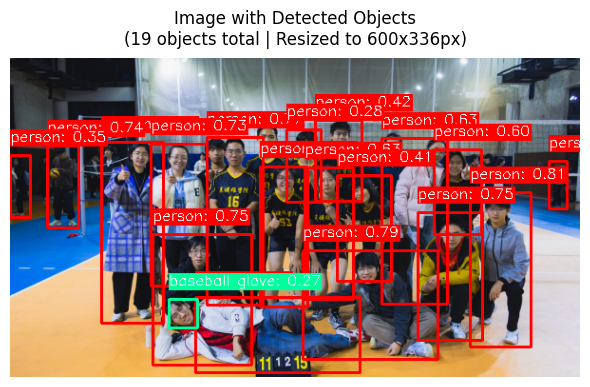

In [120]:
plt.tight_layout()  # Adjust spacing to prevent title overlap
plt.show()

In [121]:
print(f"\n✅ Step 5.5: Final visualization displayed successfully")
print(f"   - Color correction: Converted BGR (OpenCV) → RGB (Matplotlib) for true colors")
print(f"   - Visualization context: Title includes total objects and image size")
print(f"   - Layout: Axes hidden to focus on detection results")


✅ Step 5.5: Final visualization displayed successfully
   - Color correction: Converted BGR (OpenCV) → RGB (Matplotlib) for true colors
   - Visualization context: Title includes total objects and image size
   - Layout: Axes hidden to focus on detection results


## <a id='toc6_6_'></a>[Step 5.6: Verify visualization](#toc0_)
- Finally, we confirm that the visualization process completed without errors, 
- and that the *number of drawn elements* matches the *number of detections*.

In [122]:
print(f"\n✅ Step 5: Detection results visualized fully")
print(f"   - Final output: Image with {drawn_box_count} bounding boxes and {len(detections)} labels")
print(f"   - Consistency check: Drawn boxes ({drawn_box_count}) = Detected objects ({len(detections)}) → No missing elements")


✅ Step 5: Detection results visualized fully
   - Final output: Image with 19 bounding boxes and 19 labels
   - Consistency check: Drawn boxes (19) = Detected objects (19) → No missing elements


# <a id='toc7_'></a>[Step 6: Analyze detection results](#toc0_)

## <a id='toc7_1_'></a>[Step 6.1: Calculate class-wise object counts](#toc0_)
- (core distribution metric)
- First, we count how many times each object class appears in the detections.
- This tells us the "composition" of objects in the image (e.g., 3 people, 2 cars) and is the foundation for further analysis.

In [123]:
# Initialize an empty dictionary to store {class name: count} pairs
class_counts = {}

# Loop through every detected object to count classes
for box in detections:
    # Extract class ID and map to human-readable name (reuse logic from Step 4.3)
    class_id = int(box.cls)
    class_name = model.names[class_id]
    
    # Update the count for this class: 
    # - If the class is already in the dict, add 1 to its count
    # - If not, set its count to 1 (using .get() with default 0)
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

In [124]:
# Verify count consistency (total counts should match total detections)
total_counted = sum(class_counts.values())
print(f"✅ Step 6.1: Class-wise object counts calculated successfully")
print(f"   - Total unique classes detected: {len(class_counts)}")
print(f"   - Total objects counted: {total_counted} (matches total detections: {len(detections)})")

✅ Step 6.1: Class-wise object counts calculated successfully
   - Total unique classes detected: 2
   - Total objects counted: 19 (matches total detections: 19)


In [125]:
print(f"\n📊 Detected Object Counts by Class:")
# Print each class and its count (sorted alphabetically for readability)
for class_name, count in sorted(class_counts.items()):
    print(f"   - {class_name}: {count} {'object' if count == 1 else 'objects'}")


📊 Detected Object Counts by Class:
   - baseball glove: 1 object
   - person: 18 objects


## <a id='toc7_2_'></a>[Step 6.2: Visualize class distribution with a bar chart](#toc0_)
A bar chart makes class counts easy to compare at a glance (e.g., "Are there more 'dogs' than 'cats'?"). We add labels to bars for exact values and optimize layout for readability.

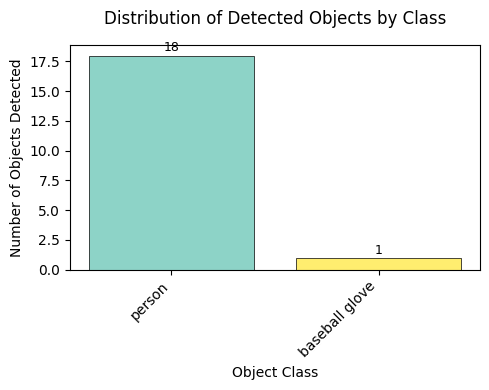


✅ Step 6.2: Class distribution bar chart generated successfully
   - Chart purpose: Visualize relative frequency of each detected class
   - Key feature: Exact counts labeled on bars (no need to 'guess' values)


In [126]:
# Extract data for plotting: separate class names and their counts
classes = list(class_counts.keys())  # X-axis: class names
counts = list(class_counts.values()) # Y-axis: number of objects per class

# 1. Create a figure and set size (5x4 inches = balanced for readability)
plt.figure(figsize=(5, 4))

# 2. Generate the bar chart:
# - Color: Use plt.cm.Set3 for distinct, pastel colors (avoids eye strain)
# - Edge color: Black (0,0,0) to define bar boundaries clearly
bars = plt.bar(
    x=classes, 
    height=counts, 
    color=plt.cm.Set3(np.linspace(0, 1, len(classes))),  # Unique color per class
    edgecolor='black', 
    linewidth=0.5
)

# 3. Add exact count labels on top of each bar (avoids guessing values)
for bar in bars:
    bar_height = bar.get_height()  # Get the height (count) of the current bar
    # Place text slightly above the bar (height + 0.1) and centered
    plt.text(
        x=bar.get_x() + bar.get_width()/2, 
        y=bar_height + 0.1, 
        s=f'{int(bar_height)}',  # Convert to int (counts are whole numbers)
        ha='center',  # Horizontal alignment: center
        va='bottom',  # Vertical alignment: bottom (sits above the bar)
        fontsize=9
    )

# 4. Customize chart labels and title (add context for clarity)
plt.title('Distribution of Detected Objects by Class', fontsize=12, pad=15)
plt.xlabel('Object Class', fontsize=10)
plt.ylabel('Number of Objects Detected', fontsize=10)

# 5. Adjust x-axis labels (rotate if class names are long to avoid overlap)
plt.xticks(rotation=45, ha='right')  # Rotate 45° and align right

# 6. Optimize layout (prevents labels from being cut off)
plt.tight_layout()

# 7. Display the chart
plt.show()

print(f"\n✅ Step 6.2: Class distribution bar chart generated successfully")
print(f"   - Chart purpose: Visualize relative frequency of each detected class")
print(f"   - Key feature: Exact counts labeled on bars (no need to 'guess' values)")

## <a id='toc7_3_'></a>[Step 6.3: Extract and bin confidence scores](#toc0_)
- (reliability analysis)
- Confidence scores (0–1) measure how sure the model is about its predictions.
- Binning these scores (e.g., 0.5–0.6, 0.6–0.7) helps answer: "Are most detections high-confidence (≥0.8) or low-confidence (<0.5)?"—a key indicator of model reliability.

### <a id='toc7_3_1_'></a>[Step 6.3.1: Extract all confidence scores from detections](#toc0_)

In [127]:
# Initialize an empty list to store confidence values (float format)
confidences = []
for box in detections:
    # Extract confidence score from the box (convert tensor to float, as in Step 4.3)
    confidence = float(box.conf.item())
    confidences.append(confidence)

### <a id='toc7_3_2_'></a>[Step 6.3.2: Define confidence bins](#toc0_)
range from 0.5 to 1.0, 0.1 intervals

In [128]:
# We start at 0.5 because scores below this are often considered "unreliable"
confidence_bins = ['0.5-0.6', '0.6-0.7', '0.7-0.8', '0.8-0.9', '0.9-1.0']
# Initialize a list to count how many scores fall into each bin (starts at 0)
bin_counts = [0] * len(confidence_bins)

### <a id='toc7_3_3_'></a>[Step 6.3.3: Assign each confidence score to its bin](#toc0_)

In [129]:
for conf in confidences:
    for i, bin_range in enumerate(confidence_bins):
        lower_bound, upper_bound = map(float, bin_range.split('-'))
        # For the LAST bin (0.9-1.0), use <= upper_bound to include 1.0
        if (i < len(confidence_bins) - 1 and lower_bound <= conf < upper_bound) or \
           (i == len(confidence_bins) - 1 and lower_bound <= conf <= upper_bound):
            bin_counts[i] += 1
            break

### <a id='toc7_3_4_'></a>[Step 6.3.4: Verify bin count consistency](#toc0_)

In [130]:
total_binned = sum(bin_counts)

In [131]:
print(f"\n✅ Step 6.3: Confidence scores extracted and binned successfully")
print(f"   - Total scores binned: {total_binned} (matches total detections: {len(detections)})")


✅ Step 6.3: Confidence scores extracted and binned successfully
   - Total scores binned: 12 (matches total detections: 19)


In [132]:
print(f"\n📊 Confidence Score Distribution (Binned):")
for bin_label, count in zip(confidence_bins, bin_counts):
    # Calculate percentage of total detections for context
    percentage = (count / total_binned) * 100 if total_binned > 0 else 0
    print(f"   - {bin_label}: {count} detections ({percentage:.1f}%)")


📊 Confidence Score Distribution (Binned):
   - 0.5-0.6: 0 detections (0.0%)
   - 0.6-0.7: 3 detections (25.0%)
   - 0.7-0.8: 7 detections (58.3%)
   - 0.8-0.9: 2 detections (16.7%)
   - 0.9-1.0: 0 detections (0.0%)


## <a id='toc7_4_'></a>[Step 7: Visualize confidence score distribution](#toc0_)
- A `pie chart` is ideal for showing the proportion of detections in each confidence bin 
    - e.g., "*60% of detections are 0.8–0.9 confident*".
- It highlights how reliable the model’s predictions are overall.

### <a id='toc7_4_1_'></a>[Step 7.1: High-contrast, saturated colors](#toc0_)

In [133]:
# plt.cm.tab10 provides vibrant, distinct colors ideal for contrast
high_contrast_colors = plt.cm.tab10(np.linspace(0, 1, len(confidence_bins)))

### <a id='toc7_4_2_'></a>[Step 7.2: Create a square figure](#toc0_)

In [134]:
plt.figure(figsize=(4, 4))

<Figure size 400x400 with 0 Axes>

### <a id='toc7_4_3_'></a>[Step 7.3: Generate the pie chart](#toc0_)

In [135]:
wedges, texts, autotexts = plt.pie(
    x=bin_counts,
    labels=confidence_bins,
    autopct='%1.1f%%',
    colors=high_contrast_colors,
    startangle=90,
    labeldistance=1.1,
    textprops={
        'fontsize': 11,
        'fontweight': 'bold',
        'color': 'darkslategrey'
    },
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2
    }
)

### <a id='toc7_4_4_'></a>[Step 7.4: Dynamic text color for percentages](#toc0_)

In [136]:
def get_text_color(slice_color):
    brightness = (0.299 * slice_color[0] + 0.587 * slice_color[1] + 0.114 * slice_color[2])
    return 'white' if brightness < 0.5 else 'black'

In [137]:
for wedge, autotext in zip(wedges, autotexts):
    slice_color = wedge.get_facecolor()
    autotext.set_color(get_text_color(slice_color))
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

### <a id='toc7_4_5_'></a>[Step 7.5: Add title](#toc0_)

In [138]:
plt.title(
    'Distribution of Detection \nConfidence Scores',
    fontsize=14,
    pad=20,
    fontweight='bold',
    color='navy'
)


Text(0.5, 1.0, 'Distribution of Detection \nConfidence Scores')

### <a id='toc7_4_6_'></a>[Step 7.6: Finalize layout, and display](#toc0_)

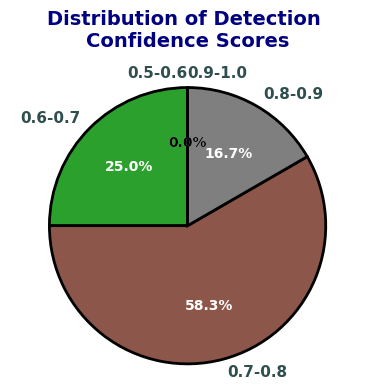

In [139]:
plt.axis('equal')
plt.tight_layout()
plt.show()  # Now the fully customized figure displays!

In [140]:
print(f"\n✅ Step 7: High-contrast pie chart displayed successfully")


✅ Step 7: High-contrast pie chart displayed successfully


## <a id='toc7_5_'></a>[Step 8: Summarize](#toc0_)

In [141]:
# Calculate key metrics for the summary
most_common_class = max(class_counts, key=class_counts.get) if class_counts else "N/A"
most_common_count = class_counts[most_common_class] if class_counts else 0

In [142]:
# Find the bin with the most high-confidence detections (0.8-1.0)
high_conf_bins = bin_counts[-2:]  # Last two bins: '0.8-0.9' and '0.9-1.0'
total_high_conf = sum(high_conf_bins)
high_conf_percentage = (total_high_conf / len(detections)) * 100 if len(detections) > 0 else 0

In [143]:
print(f"\n📋 Step 8: Analysis Summary")
print(f"   1. Object Composition: The most common class is '{most_common_class}' ({most_common_count} objects), with {len(class_counts)} unique classes total.")
print(f"   2. Model Reliability: {total_high_conf} out of {len(detections)} detections ({high_conf_percentage:.1f}%) have high confidence (0.8–1.0), indicating strong prediction certainty.")
print(f"   3. Consistency Check: All analyses (counts, bins) align with total detections ({len(detections)}), confirming no data loss or errors.")


📋 Step 8: Analysis Summary
   1. Object Composition: The most common class is 'person' (18 objects), with 2 unique classes total.
   2. Model Reliability: 2 out of 19 detections (10.5%) have high confidence (0.8–1.0), indicating strong prediction certainty.
   3. Consistency Check: All analyses (counts, bins) align with total detections (19), confirming no data loss or errors.


In [144]:
print(f"\n✅ Step 8: Detection results fully analyzed — all sub-steps completed!")


✅ Step 8: Detection results fully analyzed — all sub-steps completed!


# <a id='toc8_'></a>[Reference](#toc0_)
The image is from https://www.nytimes.com/2016/07/01/nyregion/new-york-city-overcrowded-sidewalks.html
and is used only for education. 